In [102]:
#Imports
import sys,os
os.environ['MKL_NUM_THREADS'] = '4' # set number of MKL threads to run in parallel
from quspin.operators import hamiltonian,quantum_operator
from quspin.basis import spin_basis_1d
from numpy.random import uniform,seed
from joblib import delayed,Parallel
from itertools import combinations
from functools import partial
import numpy as np
import gc
import pickle
from time import time
from quspin.tools.measurements import diag_ensemble
from quspin.tools.evolution import ED_state_vs_time
import matplotlib.pyplot as plt
from matplotlib.pyplot import plot, show, figure, xlabel, ylabel, xscale, yscale, legend, loglog
from numpy import pi, exp, log, sin , cos, tan, log, array,sqrt
import numpy.linalg as la
import quspin
timestamp = time()

In [109]:
###Functions
def timer(timestamp):
    #Timer Function
    print("time =", time()-timestamp)
    return

def fin_string(ns,s): #ns = length of string s = operator
    #Max string length
    if ns>L:
        ns=L
    else:
        pass
    
    
    def linears(start,m):
        #Find all indices in string
        ind=[i%L for i in range(start,start+ns)]
     #All combinations
        perm=list(combinations(ind,m))
      #Add each coupling to operator
        for j in range(len(perm)):
#            S_temp=[((-1)**m)*(2**m)/(L*(2**ns))] ########### Down #
            S_temp=[1/(L*(2**ns))] ###################### Up
            for i in range(len(perm[j])):
                S_temp.append(perm[j][i])
        ##Saving Couplin gs lists
            if j==0: 
                S_temp_2=[S_temp]
            else: 
                S_temp_2.append(S_temp)
        return S_temp_2
    #List to store orders of interaction
    o_type=np.empty(ns,dtype=object)
    
    for i in range(ns):
        #ex: "z"*2= "zz"
        o_type[i]=s*(i+1)

    #Iterate over each Site
    for k in range(L):
        #Iterate over different string lengths
      for i in range(ns):
          #First item defines list
          if k==0 and i==0:
              #example: i = 0 operator_list = [['x', linears(k,1)]]
              operator_list=[[o_type[i],linears(k,i+1)]]
          else:
              operator_list.append([o_type[i],linears(k,i+1)])
    S_temp_1 = [[(1/((ns*2**ns))), i] for i in range(ns)]
    #S_temp_1 = [[(1/((ns*2**(ns)))), 1] ]
    operator_list.append(["I",S_temp_1])
    operator_dict=dict(S=operator_list)
    O = quantum_operator(operator_dict,basis=basis,check_symm=False,check_herm=False)
    return O, operator_list
def commutator(A, B):
    return A @ B - B @ A


/var/folders/tb/9nr_hj116ln_8s6hck886ppc0000gn/T/ipykernel_9339/1960560042.py:8: RuntimeWarning: divide by zero encountered in matmul
  return A @ B - B @ A
/var/folders/tb/9nr_hj116ln_8s6hck886ppc0000gn/T/ipykernel_9339/1960560042.py:8: RuntimeWarning: overflow encountered in matmul
  return A @ B - B @ A
/var/folders/tb/9nr_hj116ln_8s6hck886ppc0000gn/T/ipykernel_9339/1960560042.py:8: RuntimeWarning: invalid value encountered in matmul
  return A @ B - B @ A
/var/folders/tb/9nr_hj116ln_8s6hck886ppc0000gn/T/ipykernel_9339/2072709508.py:5: RuntimeWarning: divide by zero encountered in matmul
  return np.real(la.trace(x.conj().T @ x))
/var/folders/tb/9nr_hj116ln_8s6hck886ppc0000gn/T/ipykernel_9339/2072709508.py:5: RuntimeWarning: overflow encountered in matmul
  return np.real(la.trace(x.conj().T @ x))
/var/folders/tb/9nr_hj116ln_8s6hck886ppc0000gn/T/ipykernel_9339/2072709508.py:5: RuntimeWarning: invalid value encountered in matmul
  return np.real(la.trace(x.conj().T @ x))
/var/folders

81920.0
5119.999680000021


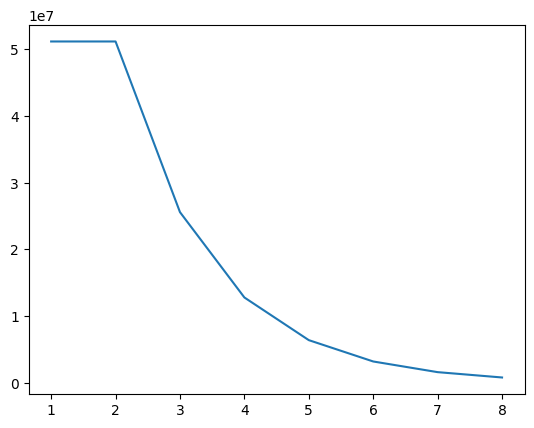

In [ ]:
###### Model parameters
#Length of chain
L = 10
#X field
J1 = 1 #NN term 
J2 = 0
h0 = 0
#Basis being projected
op = "x"
ns = np.arange(1,L+1)

###Using Quantum_Operator to build hamitlonian 
basis = spin_basis_1d(L, pauli = -1)
#NN Sigma x term (Periodic Boundary Conditions)
NN_sigma_x = [ [-J1, i, (i+1)%L] for i in range(L)]
NNN_sigma_x = [ [-J2, i, (i+1)%L] for i in range(L)]

#site coupling lists
sigma_z = [ [-1, i] for i in range(L)]
#Define the static H (that doesn't change)
static_H = [ ["xx", NN_sigma_x], ["xx",NNN_sigma_x] ] 
#The z field is the quench
Quenching_H = [["z", sigma_z]]
#Define operator dictionary
operator_dict = dict(H0= static_H, Quench = Quenching_H)
#Build Hamiltonian
H = quantum_operator(operator_dict, basis=basis, check_herm= False, check_symm = False)
#Define Parameters
params_dict = dict( H0=1, Quench=h0)
#Build H0
H0 = H.tohamiltonian(params_dict)
#Find eigenvalues
E,V = np.linalg.eigh(H0.todense())
#Convert matrix to array
V = np.array(V)
#Ground state of unquenched hamiltonian
V0= V[:,0]
D = len(V0)

#Compute AGP: 
partialH= [ [-1, i] for i in range(L)]
partialH = [["z", partialH]]
operator_dict=dict(S=partialH)
partialH= quantum_operator(operator_dict,basis=basis,check_symm=False,check_herm=False)
partialH = array(partialH.todense())
H0=array(H0.todense())
#Turn Parital H to AGP
PH = partialH             
x=commutator(PH,H0)

print(norm(x))


PH_eig = V.conj().T @ PH @ V

eta = 1e-3
dE  = E[:,None] - E[None,:]

A_eig = -1j * PH_eig / (dE + 1j*eta)
A_eig = V@ A_eig @V.conj().T
vals=[]
for n in np.arange(1,9):

    P = array(fin_string(n,op)[0].todense())
    y = commutator(A_eig,P)

    vals.append(norm(y))



5119.999680000021


/var/folders/tb/9nr_hj116ln_8s6hck886ppc0000gn/T/ipykernel_9339/1960560042.py:8: RuntimeWarning: divide by zero encountered in matmul
  return A @ B - B @ A
/var/folders/tb/9nr_hj116ln_8s6hck886ppc0000gn/T/ipykernel_9339/1960560042.py:8: RuntimeWarning: overflow encountered in matmul
  return A @ B - B @ A
/var/folders/tb/9nr_hj116ln_8s6hck886ppc0000gn/T/ipykernel_9339/1960560042.py:8: RuntimeWarning: invalid value encountered in matmul
  return A @ B - B @ A
/var/folders/tb/9nr_hj116ln_8s6hck886ppc0000gn/T/ipykernel_9339/2072709508.py:5: RuntimeWarning: divide by zero encountered in matmul
  return np.real(la.trace(x.conj().T @ x))
/var/folders/tb/9nr_hj116ln_8s6hck886ppc0000gn/T/ipykernel_9339/2072709508.py:5: RuntimeWarning: overflow encountered in matmul
  return np.real(la.trace(x.conj().T @ x))
/var/folders/tb/9nr_hj116ln_8s6hck886ppc0000gn/T/ipykernel_9339/2072709508.py:5: RuntimeWarning: invalid value encountered in matmul
  return np.real(la.trace(x.conj().T @ x))


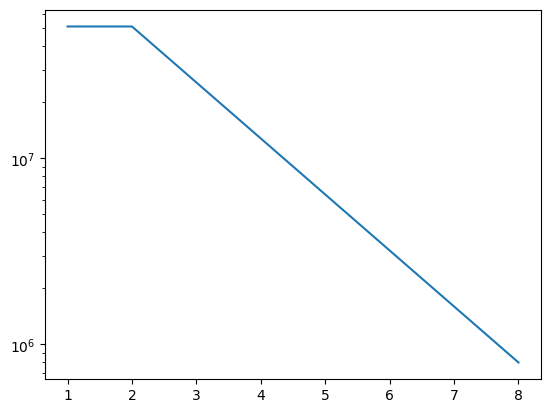

In [302]:
plot(np.arange(1,9),vals)

print(norm(commutator(A_eig,H0)))
yscale("log")

/var/folders/tb/9nr_hj116ln_8s6hck886ppc0000gn/T/ipykernel_9339/1960560042.py:40: RuntimeWarning: divide by zero encountered in matmul
  PH_eig = V.conj().T @ partialH @ V
/var/folders/tb/9nr_hj116ln_8s6hck886ppc0000gn/T/ipykernel_9339/1960560042.py:40: RuntimeWarning: overflow encountered in matmul
  PH_eig = V.conj().T @ partialH @ V
/var/folders/tb/9nr_hj116ln_8s6hck886ppc0000gn/T/ipykernel_9339/1960560042.py:40: RuntimeWarning: invalid value encountered in matmul
  PH_eig = V.conj().T @ partialH @ V
/var/folders/tb/9nr_hj116ln_8s6hck886ppc0000gn/T/ipykernel_9339/1960560042.py:52: RuntimeWarning: divide by zero encountered in matmul
  vals.append(np.real(la.trace(x.conj().T @ x)))
/var/folders/tb/9nr_hj116ln_8s6hck886ppc0000gn/T/ipykernel_9339/1960560042.py:52: RuntimeWarning: overflow encountered in matmul
  vals.append(np.real(la.trace(x.conj().T @ x)))
/var/folders/tb/9nr_hj116ln_8s6hck886ppc0000gn/T/ipykernel_9339/1960560042.py:52: RuntimeWarning: invalid value encountered in ma

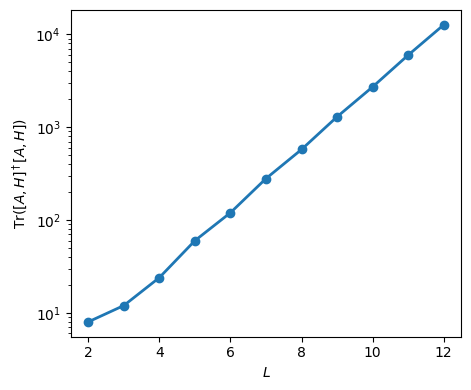

In [193]:
import numpy as np
import matplotlib.pyplot as plt
import numpy.linalg as la
from quspin.operators import quantum_operator
from quspin.basis import spin_basis_1d

def commutator(A,B):
    return A @ B - B @ A

Ls = range(2,13)
vals = []

for L in Ls:
    J1, J2, h0 = 1, 0, 0

    basis = spin_basis_1d(L, pauli=-1, pblock=1)

    NN_sigma_x  = [[-J1, i, (i+1)%L] for i in range(L)]
    NNN_sigma_x = [[-J2, i, (i+1)%L] for i in range(L)]
    sigma_z     = [[-1, i] for i in range(L)]

    static_H   = [["xx", NN_sigma_x], ["xx", NNN_sigma_x]]
    Quench_H   = [["z", sigma_z]]
    operator_dict = dict(H0=static_H, Quench=Quench_H)

    H = quantum_operator(operator_dict, basis=basis,
                          check_herm=False, check_symm=False)

    H0 = np.array(H.tohamiltonian(dict(H0=1, Quench=h0)).todense())

    E, V = la.eigh(H0)

    # partial_h H
    partialH = quantum_operator(dict(S=[["z", sigma_z]]),
                                basis=basis,
                                check_herm=False,
                                check_symm=False)
    partialH = np.array(partialH.todense())

    PH_eig = V.conj().T @ partialH @ V

    eta = 1e-3
    dE  = E[:,None] - E[None,:]

    A_eig = -1j * PH_eig / (dE + 1j*eta)
    np.fill_diagonal(A_eig, 0.0)

    A = V @ A_eig @ V.conj().T

    x = commutator(A, H0) 

    vals.append(np.real(la.trace(x.conj().T @ x)))

# plot
plt.figure(figsize=(5,4))
plt.plot(Ls, vals, "o-", lw=2)
plt.xlabel(r"$L$")
plt.ylabel(r"$\mathrm{Tr}([A,H]^\dagger[A,H])$")
plt.tight_layout()
#loglog()
yscale("log")

In [269]:
Ls = np.arange(2,13)
ns = [2,4,6]
vals = []
def norm(x):
    return np.real(la.trace(x.conj().T @ x))
P_vals = np.zeros((len(ns),len(Ls)))
for Li in range(len(Ls)):
    L = int(Ls[Li])
    print(L)
    J1, J2, h0 = 1, 0, 0

    basis = spin_basis_1d(L, pauli=-1)
    
    NN_sigma_x  = [[-J1, i, (i+1)%L] for i in range(L)]
    NNN_sigma_x = [[-J2, i, (i+1)%L] for i in range(L)]
    sigma_z     = [[-1, i] for i in range(L)]

    static_H   = [["xx", NN_sigma_x], ["xx", NNN_sigma_x]]
    Quench_H   = [["z", sigma_z]]
    operator_dict = dict(H0=static_H, Quench=Quench_H)

    H = quantum_operator(operator_dict, basis=basis,
                          check_herm=False, check_symm=False)

    H0 = np.array(H.tohamiltonian(dict(H0=1, Quench=h0)).todense())

    E, V = la.eigh(H0)

    # partial_h H
    partialH = quantum_operator(dict(S=[["z", sigma_z]]),
                                basis=basis,
                                check_herm=False,
                                check_symm=False)
    partialH = np.array(partialH.todense())

    PH_eig = V.conj().T @ partialH @ V

    eta = 1e-3
    dE  = E[:,None] - E[None,:]

    A_eig = -1j * PH_eig / (dE + 1j*eta)
    np.fill_diagonal(A_eig, 0.0)

    A = V @ A_eig @ V.conj().T
    #Calcualtions
    x = commutator(A, H0) 
    vals.append(norm(x))
    for i in range(len(ns)):
        n = ns[i]

        P = array(fin_string(n,op)[0].todense())
        x = commutator(A,P)
        P_vals[i,Li] = norm(x)






2
3
4
5
6
7
8
9


/var/folders/tb/9nr_hj116ln_8s6hck886ppc0000gn/T/ipykernel_9339/2072709508.py:36: RuntimeWarning: divide by zero encountered in matmul
  PH_eig = V.conj().T @ partialH @ V
/var/folders/tb/9nr_hj116ln_8s6hck886ppc0000gn/T/ipykernel_9339/2072709508.py:36: RuntimeWarning: overflow encountered in matmul
  PH_eig = V.conj().T @ partialH @ V
/var/folders/tb/9nr_hj116ln_8s6hck886ppc0000gn/T/ipykernel_9339/2072709508.py:36: RuntimeWarning: invalid value encountered in matmul
  PH_eig = V.conj().T @ partialH @ V
/var/folders/tb/9nr_hj116ln_8s6hck886ppc0000gn/T/ipykernel_9339/2072709508.py:5: RuntimeWarning: divide by zero encountered in matmul
  return np.real(la.trace(x.conj().T @ x))
/var/folders/tb/9nr_hj116ln_8s6hck886ppc0000gn/T/ipykernel_9339/2072709508.py:5: RuntimeWarning: overflow encountered in matmul
  return np.real(la.trace(x.conj().T @ x))
/var/folders/tb/9nr_hj116ln_8s6hck886ppc0000gn/T/ipykernel_9339/2072709508.py:5: RuntimeWarning: invalid value encountered in matmul
  return n

10
11
12


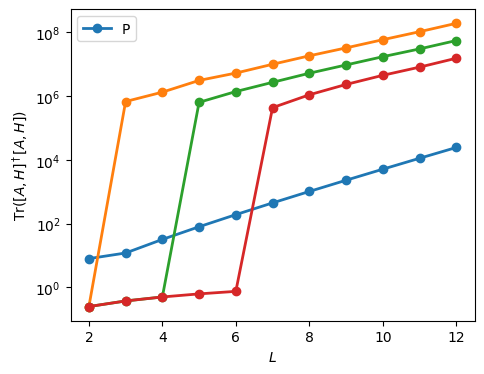

In [271]:
# plot
plt.figure(figsize=(5,4))
plt.plot(Ls, (array(vals)), "o-", lw=2,label="P")
plot(Ls,(P_vals[0,:]),"o-",lw=2)
plot(Ls,(P_vals[1,:]),"o-",lw=2)
plot(Ls,(P_vals[2,:]),"o-",lw=2)
#plot(Ls,(P_vals[3,:]),"o-",lw=2)

legend()
plt.xlabel(r"$L$")
plt.ylabel(r"$\mathrm{Tr}([A,H]^\dagger[A,H])$")
plt.tight_layout()
#loglog()
yscale("log")